# 1. 연관 분석?

## 1-1. 정의

상품·서비스 구매 등 일련의 거래 안에 존재하는 **항목 간의 일정한 연관 규칙을 발견하는 분석**. 장바구니 분석이라고 보면 됨

상품 거래뿐 아니라 다른 분야에도 활용됨.

- **OTT 서비스**: 시청 패턴 분석해 맞춤 콘텐츠 추천
- **금융 기관**: 거래 패턴으로 사기 탐지, 맞춤 금융상품 기획
- **의료 분야**: 증상·질병 패턴 분석해 예방 조치 마련
- **요식업계**: 인기 메뉴 조합을 찾아 세트 메뉴 개발

정답값이 없어 **비지도 학습** 대표 알고리즘: `Apriori`, `FP-Growth`.

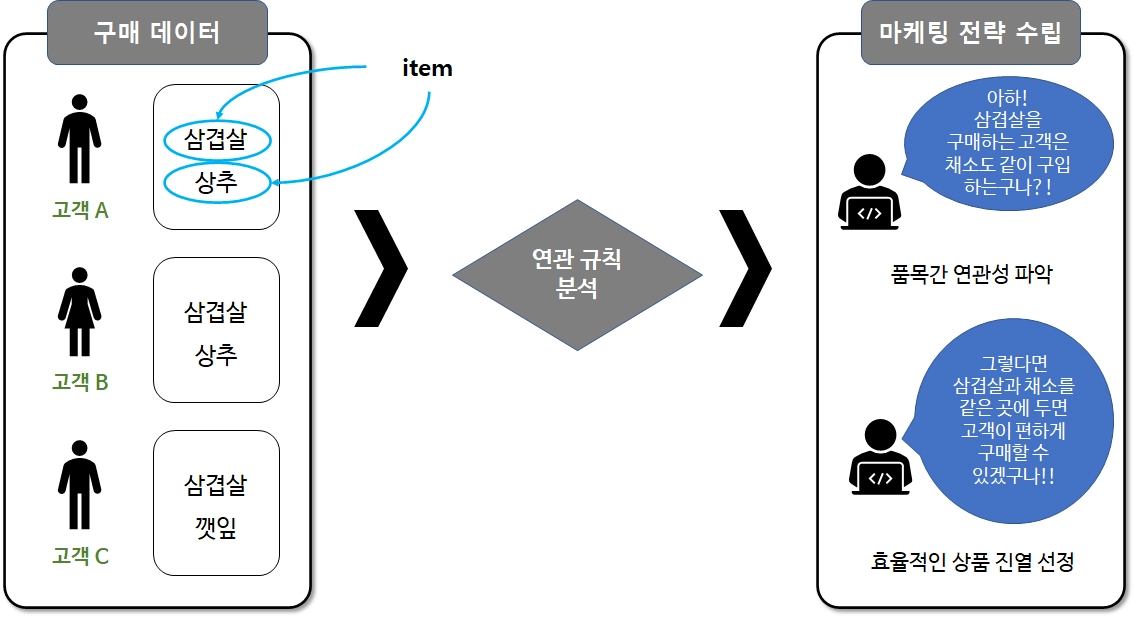

## 1-2. 연관규칙 분석

**형태**: `A →(이면) B`의 if-then 형식. 조건절·결과절을 구성하는 아이템들의 집합을 **아이템 집합**이라 함.
- 예: "라면을 구매하는 사람은 달걀도 함께 산다" → 라면 구매=조건절, 달걀 구매=결과절, 아이템 집합은 라면, 달걀
- 아이템 집합에 여러 개 아이템이 들어가도 되지만 **상호 배반**이어야 함!!

** 주의할점: 인과관계는 알 수 없다** — 연관규칙은 상관관계만 파악할 뿐 인과관계는 알 수 없음.
- 예: `A→B` 신뢰도 0.8 = "A를 산 사람 중 80%는 B도 샀다" → 함께 자주 나타난다는 패턴일뿐이고 원인-결과로 볼 수는 x
- 이유 1 **관찰 데이터**이기 때문  2 **방향성은 수학적 비율일 뿐** 3 **상관관계 ≠ 인과관계** 



# 2. 주요 개념

## 2-1. 적절한 연관규칙의 조건

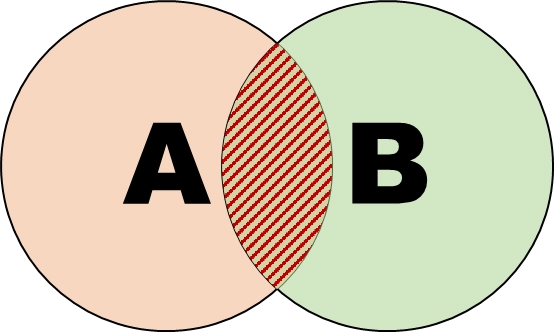

1. 두 품목이 함께 구매된 경우의 수가 일정 수준 이상 (**일정 이상의 지지도**)
2. A를 포함하는 거래 중 B를 구입하는 경우의 수가 일정 수준 이상 (**일정 이상의 신뢰도**)

** 지지도**: 전체 거래 중 A와 B가 동시에 포함된 거래의 비율. $지지도 = P(A \cap B)$
- 지지도가 낮으면?: 1 우연일 수 있는 규칙 포함  2 실행 가능한 인사이트 도출 어려움 
- → **"이 규칙이 현실에서 의미 있는가?"를 판단하는 기준임


**신뢰도**: (조건부확률 -> A를 구매했을때 B도 구매할 확률). $신뢰도=\frac{P(A\cap B)}{P(A)}=\frac{지지도}{P(A)}$
- 신뢰도가 낮으면: 1 의미 없는 연관규칙  2 추천 실패로 이어짐 



## 2-2. 연관 분석의 평가 측도

**향상도**: 핵심 아이디어는 "A와 B가 우연히 함께 등장할 확률과 실제 함께 등장할 확률을 비교하자."

$$향상도 = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}$$

- **독립일 때 기댓값**: A, B가 독립이면 $P(A\cap B)=P(A)\cdot P(B)$ (A를 샀다는 사실이 B 살 확률에 영향 없음) → 향상도=1. 독립이 아니면 $P(A\cap B)=P(A)P(B|A)=P(B)P(A|B)$ (서로 영향을 줌) → 실제 관측값에 따라 향상도가 1보다 크거나 작음
- **실제 동시발생 확률**이 기댓값 $P(A)\cdot P(B)$보다 크면 → 양의 연관성(A 사면 B도 잘 삼), 작으면 → 음의 연관성(A 산 사람은 B 잘 안 삼)

| 향상도 > 1 | 우연적 기회보다 높은 확률 (양의 상관관계) |
| --- | --- |
| 향상도 = 1 | 독립 |
| 향상도 < 1 | 우연적 기회보다 낮은 확률 (음의 상관관계) |

규칙의 효용성은 **지지도·신뢰도·향상도 세 가지를 모두 반영해 평가**함 —다 확인하기 어려워서 일정 수준의 지지도·신뢰도를 요구하는 것.

**예시(거래 10건, 목표: 라면 구매 시 햇반 구매 여부)**
- $지지도=P(라면\cap 햇반)=3/10=0.3$
- $신뢰도=P(햇반|라면)=3/8=0.375$
- $향상도=\frac{0.3}{0.8\times0.3}=1.25$ → 우연보다 높은 확률, 라면 구매 고객은 그렇지 않은 고객보다 햇반 구매 상대적 확률이 25% 높음



# 3. 활용 사례 — 월마트 
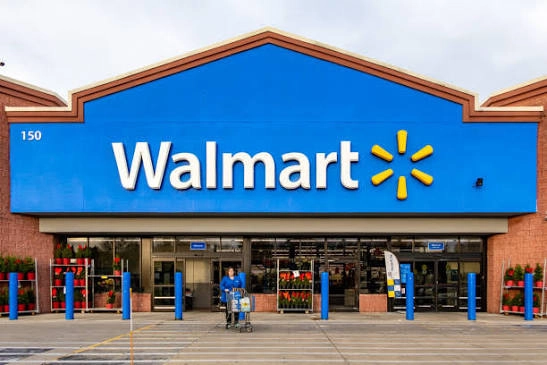

**"허리케인이 오면 딸기맛 팝타르트를 트럭으로 실어 보내라"**: 2004년 8월 허리케인 프랜시스 접근때 월마트 CIO 린다 딜먼은 몇 주 전 허리케인 찰리 때의 판매 데이터를 분석하도록 지시, 사후 대응 대신 사전 예측으로 전환하고자 했음. 목표는 아무도 예상 못한 패턴을 찾는 것.

분석 결과: 딸기맛 팝타르트가 허리케인 직전 평상시의 **약 7배** 속도로 팔림. 판매 1위는 맥주. 팝타르트는 가열·냉장 불필요, 유통기한 김 → 정전 상황에 최적화된 식품.

월마트는 허리케인 경로상 매장에 팝타르트·맥주 트럭을 미리 내려보냈고 물량은 빠르게 소진됨. 이후 표준 재난 대응 프로세스가 됨 — 2018년 허리케인 플로렌스 때는 2017년 하비·어마·마리아 데이터를 재분석해 35만 상자 이상 사전 배송.

**연관 분석 관점 해석**
- **지지도**: 허리케인 경보 기간 중 '재난 대비 용품'과 '딸기 팝타르트'가 함께 담긴 장바구니 비중 — 평상시엔 낮았지만 재난 상황에서 크게 상승. 특정 조건(재난 경보)에서만 유의미해지는 조합을 찾아냄 — **전체 기간을 통으로 분석했다면 묻혔을 규칙**이라는 게 핵심.
- **신뢰도**: A(재난 대비 물품 구매) → B(팝타르트 함께 구매)의 P(B|A)가 충분히 높았음 — "재난 대비 고객은 조리 필요 없는 간편식을 함께 산다 → 함께 진열하면 매출로 직결된다"고 판단.

- **향상도**: 평상시 대비 약 7배 → Lift≈7, 1보다 훨씬 큼 → A·B가 독립이 아니며 강한 양의 상관 존재. 월마트는 "왜 하필 딸기맛인가"라는 인과는 설명 못했지만, 향상도가 높다는 사실만으로 물류 의사결정을 실행함 — **연관 분석이 인과가 아닌 동시발생 패턴을 다루는 기법**임을 보여주는 사례.


# 4. 연관 분석의 알고리즘들

## 4-1. Apriori 알고리즘

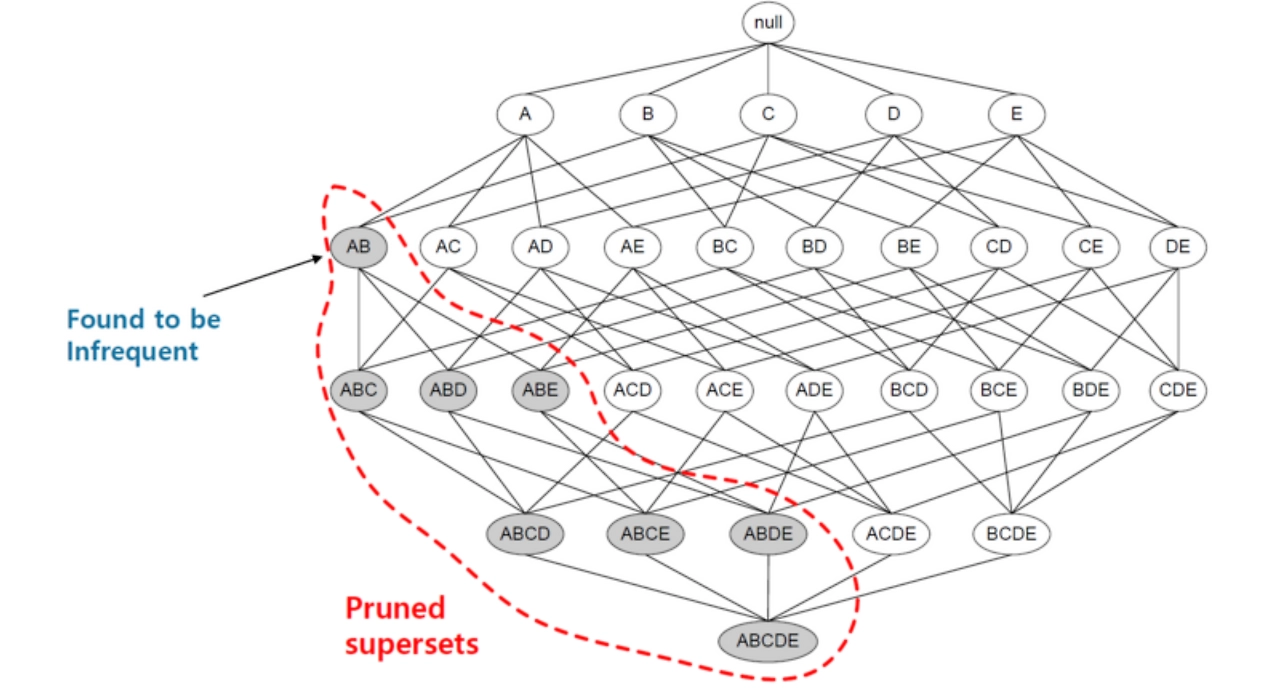

**배경**: 연관 규칙을 찾기 위해 가능한 모든 조합(A→B로 표현되는 모든 경우의 수, A·B는 복합조건일 수도 있음)을 시도하는 건 비효율적이다

**개념**: 상위 조합에서부터 차례로 스캔하며, 특정 조합이 자주 발생하지 않으면 그 결과물로 탄생하는 후속 조합들까지 모두 후보에서 배제하는 알고리즘. 집합 {A,B}의 지지도가 최소 지지도를 못 넘으면, {A,B}를 포함한 {A,B,C}, {A,B,D} 등도 모두 한번에 제거됨 → 연산량 감소. **장점**: 하나의 조합만 검사해도 파생 조합들까지 배제 가능해 시간·연산량을 효과적으로 줄임.

**프로세스** 
1. **단일 항목 집합 생성**: 모든 개별 상품 지지도 계산 → 최소 지지도 넘는 것만 다음 단계로
2. **2개 항목 집합 생성**: 선별된 상품들로 2개 조합 생성 → 지지도 계산, 최소 지지도 미달 시 제거
3. **더 큰 항목 집합 생성**: 3개 이상 조합 생성·지지도 계산·제거를 더 이상 조합 생성 불가할 때까지 반복
4. **최종 빈발 항목 집합 선정**: 남은 빈발 항목 집합으로 연관 규칙 생성, 지지도·신뢰도·향상도 계산해 유용한 규칙 선택

**예시** (거래 7건, 최소 지지도 3/7, 최소 신뢰도 0.8)
- 단일 항목: 맥주 3/7, 치킨 6/7, 햄버거 4/7, 라면 5/7 (전부 통과)
- 2개 항목: 맥주·햄버거(1/7), 맥주·라면(2/7) 제거, 나머지(맥주·치킨 3/7, 치킨·햄버거 3/7, 치킨·라면 4/7, 햄버거·라면 3/7) 통과
- 3개 항목: 전부 최소 지지도 미달 → 알고리즘 종료
- 최종 빈발 항목: {맥주,치킨}, {치킨,햄버거}, {치킨,라면}, {햄버거,라면}
- 신뢰도 0.8 이상 규칙: 맥주→치킨(3/3=1.0), 라면→치킨(4/5=0.8)
- 향상도: 맥주→치킨 = $\frac{1.0}{6/7}=1.167$(양의 상관), 라면→치킨 = $\frac{0.8}{4/7}=0.714$(음의 상관)

**장단점**: 장점 — 수많은 상품 연관 구매 패턴 발견, 원리가 간단하고 이해·분석 용이. 단점 — 데이터가 커질수록 여전히 속도가 느려짐.

**코드**
```python
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

frequent_itemsets = apriori(df, min_support=0.06, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)
top_rules = rules.sort_values(by='lift', ascending=False).head()
```

## 4-2. FP-Growth 알고리즘

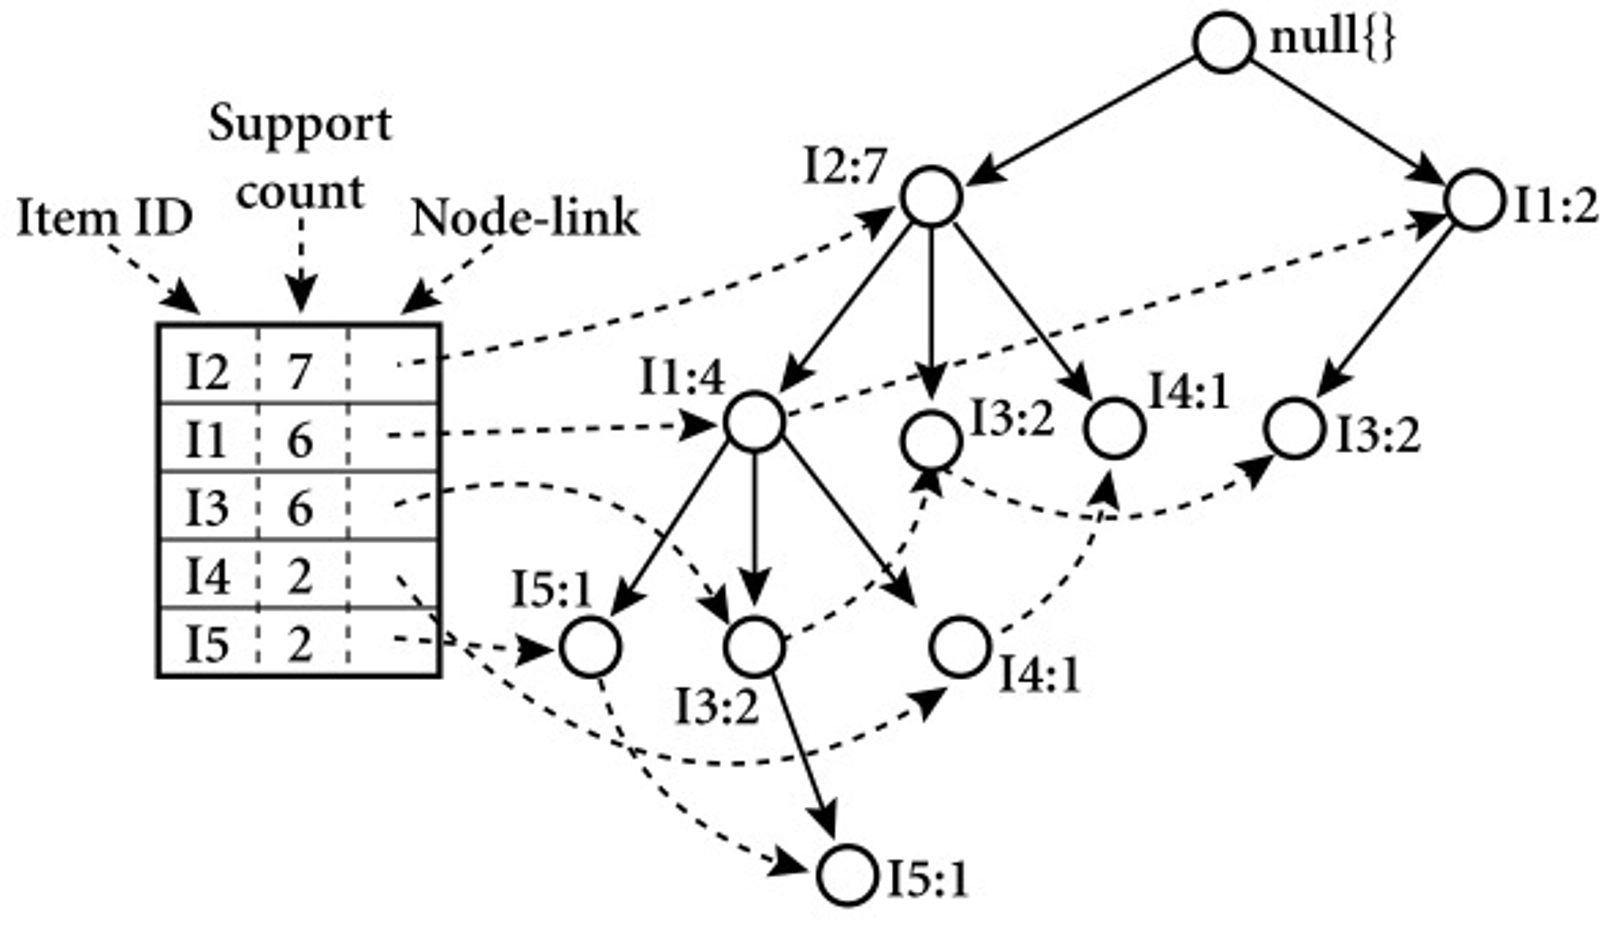

**배경**: Apriori는 각 단계마다 데이터를 다시 스캔해야 해서 데이터가 커질수록 여전히 느림!

**소개**: 빈발 품목 집합을 효율적으로 찾는 알고리즘. **FP-Tree**를 이용해 Apriori를 효과적으로 구현. 모든 거래를 확인해 아이템별 지지도를 계산하고 최소 지지도 이상만 선택 → 빈도 높은 순서로 정렬 → 부모 노드 중심으로 거래를 자식 노드로 추가하며 tree 생성  → 모든 거래에 반복해 FP-Tree를 만들고 최소 지지도 이상 패턴 추출.

**프로세스**
1. **데이터셋 확인**: 예 — 초장만 9명, 과메기만 40명, 과메기+김 50명, 과메기+김+초장 1명
2. **빈도순 재정렬**: 거래별로 가장 자주 구매된 항목이 먼저 오도록 정렬. 예: 과메기(91)-김(51)-초장(10)
3. **FP-트리 생성**: 재정렬된 데이터로 트리 생성. 각 거래를 노드로 표현, 동일 항목은 기존 노드에 연결해 빈도 증가, 새 항목은 새 노드 추가. 빈도 높은 아이템일수록 root에 더 가까운 노드가 됨. 모든 itemset을 하나씩 추가해가며 최종 FP-tree 완성
4. **빈발 항목 집합 추출**: FP-트리를 바탕으로 특정 항목 기준 부분 트리를 만들어 빈발 항목 집합을 빠르게 도출
5. **연관 규칙 도출**: 도출된 빈발 항목 집합으로 연관 규칙을 만들고 지지도·신뢰도·향상도 계산해 유용한 규칙 선택 

**장단점**: 장점 — 데이터를 두 번만 스캔하는 Tree 구조라 Apriori보다 훨씬 빠름, 후보 Itemset 생성 없이 Tree만 구성하면 끝. 
단점 — 대용량 데이터셋에서 메모리를 효율적으로 쓰지 못함, Apriori보다 설계가 어렵고 지지도 계산은 FP-Tree가 만들어져야 가능.

